In [ ]:
import os
desired_root_name = "dark-matter-sbi" 
while os.path.basename(os.getcwd()) != desired_root_name:
    os.chdir(os.path.abspath(os.path.join(os.getcwd(), "..")))
    
import numpy as np
import matplotlib.pyplot as plt

In [4]:
import WimPyDD as WD
#help(WD)

<div align="center">

<span style="font-size: 2.0em;">Signal routines</span>

</div>

$\bigl(\frac{\mathrm{d}\sigma}{\mathrm{d}E_R}\bigr)_T$

In [5]:
#WD.dsigma_der(element_obj, hamiltonian_obj, mchi, v, er, **args)
"""
    element_obj: Defines a nuclear target T
    hamiltonian_obj: Defines an effective Hamiltonian 
    mchi: WIMP mass (in GeV)
    v: WIMP velocity (in km/s)
    er: Recoil energy (in keV)
    args: Passes the parameters of the Wilson coefficients defined in the Hamiltonian
    Output: An array containing the differential cross section normalized to cm^2/keV for each of the ni isotopes contained in element.isotopes. 
""";
#help(WD.dsigma_der)

$\bigl(\frac{\mathrm{d}R}{\mathrm{d}E_R}\bigr)_T$

In [6]:
# WD.diff_rate(target_obj,hamiltonian_obj,mchi,energy,vmin,delta_eta, **args)
"""
    target_obj: Either a single element or a combination of elements with stoichiometric coefficients
    hamiltonian_obj: Defines an effective Hamiltonian 
    mchi: WIMP mass (in GeV)
    energy: Interpreted as the electron-equivalent energy E_ee for the elements that have the quenching attribute, otherwise as the recoil energy E_R (in keV) 
            Quenching is an attribute of the experimental set-up, so can be added to a target using the experiment class
    vmin: Array containing the v_k (in km/s)
    delta_eta: Array containing the delta_eta (in km/s)
    args: Passes the parameters of the Wilson coefficients defined in the Hamiltonian
    Output: Diffential rate in units of events/keV (events/kg/day/kev if exposure=1)
""";
#help(WD.diff_rate)

$S^{(0,1)}_{[E'_1,E'_2]}$

In [7]:
# WD.wimp_dd_rate(exp_obj, hamiltonian_obj, vmin, delta_eta, mchi, **args)
"""
    exp_obj: Object of the experiment class, which contains all the required information about the experimental set-up, including the energy bins where the rate is integrated 
    hamiltonian_obj: Defines an effective Hamiltonian 
    mchi: WIMP mass (in GeV)
    vmin: Array containing the v_k (in km/s)
    delta_eta: Array containing the delta_eta (in km/s)
    args: Passes the parameters of the Wilson coefficients defined in the Hamiltonian
    Output: Two arrays with the centers of the bins and the corresponding expected rates calculated using the master equation
""";
#help(WD.wimp_dd_rate)

<div align="center">

<span style="font-size: 2.0em;">Main classes</span>

</div>

### Element

In [8]:
Xe = WD.element("Xe") # Xe = WD.Xe

print("Isotopic atomic number: ", Xe.a)
print("Isotopic natural abundances: ", Xe.abundance)
#print("Quenching factor: ", Xe.quenching) # Only available if the element belongs to the target of an experiment object
#print("Array of nuclear response functions W^tau,tau'_l :", Xe.func_w)
print("Isotopes: ", Xe.isotopes)
print("Isotopic masses: ", Xe.mass)
print("Full name: ", Xe.name)
print("Array with isotopic numbers of targets per kg: ", Xe.nt_kg)
print("Array with isotopic spins: ", Xe.spin)
print("Element symbol: ", Xe.symbol)
print("Atomic number: ", Xe.z, "\n")

print(Xe) # Quick overview of the element object

#help(WD.element)

Isotopic atomic number:  [124 126 128 129 130 131 132 134 136]
Isotopic natural abundances:  [0.00095 0.00089 0.0191  0.26401 0.04071 0.21232 0.26909 0.10436 0.08857]
Isotopes:  ['124Xe' '126Xe' '128Xe' '129Xe' '130Xe' '131Xe' '132Xe' '134Xe' '136Xe']
Isotopic masses:  [115.444 117.306 119.168 120.099 121.03  121.961 122.892 124.754 126.616]
Full name:  xenon
Array with isotopic numbers of targets per kg:  [4.35276036e+21 4.07784918e+21 8.75133926e+22 1.20965501e+24
 1.86527236e+23 9.72819032e+23 1.23293083e+24 4.78162181e+23
 4.05814722e+23]
Array with isotopic spins:  [0.  0.  0.  0.5 0.  1.5 0.  0.  0. ]
Element symbol:  Xe
Atomic number:  54 

xenon, symbol Xe, atomic number 54, average mass 122.322, 9 isotopes.


### Target


In [9]:
target = WD.target("C3F8") # Octafluoropropane 

print("Target formula: ", target.formula)
print("Target mass: ", target.mass)
print("Stoichiometric coefficients of each elements in the target: ", target.n)
print("Number of element types in the target: ", target.n_targets)
print("Total mass in kg unit per mol of each element: ", target.nt_kg, "\n")

print(target) # Quick overview of the target object

#help(WD.target)

Target formula:  C3F8
Target mass:  175.058723
Stoichiometric coefficients of each elements in the target:  [3 8]
Number of element types in the target:  2
Total mass in kg unit per mol of each element:  [9.60469705e+24 2.56125255e+25] 

C3F8 contains:
carbon, symbol C, atomic number 6, average mass 11.182, 2 isotopes.
fluorine, symbol F, atomic number 9, average mass 17.689, 1 isotopes.
Isotope-averaged mass: 175.058723


In [10]:
carbon_element_obj = target.element[0]
fluorine_element_obj = target.element[1]

print("Type of target: ", type(target))
print("Type of carbon_element_obj: ", type(carbon_element_obj))
print("Type of fluorine_element_obj: ", type(fluorine_element_obj))

Type of target:  <class 'WimPyDD.package.target'>
Type of carbon_element_obj:  <class 'WimPyDD.package.element'>
Type of fluorine_element_obj:  <class 'WimPyDD.package.element'>


In [11]:
#Alternatively
c3f8 = 3*WD.C + 8*WD.F
print(c3f8.element[0])
print(c3f8.element[1])

carbon, symbol C, atomic number 6, average mass 11.182, 2 isotopes.
fluorine, symbol F, atomic number 9, average mass 17.689, 1 isotopes.


### Effective Hamiltonian

In [12]:
# Pseudocode for defining an effective Hamiltonian

# wc = {n1: func1, n2: func2, ...} # Wilson coefficients as a dictionary, ni: Integer for the operator number following Anand et al. [e.g. n1=4, n2=6]
#                                                                         or  Tuple (X,s,l) following Gondolo et al. [e.g. n1=('Sigma',1,0), n2=('Sigma',1,2)]
#                                                                         funci: function for the operator ni of arbitrary parameters pari (e.g. mass, delta, q)

# hamiltonian_obj = WD.eft_hamiltonian("name", wc)

# def func1(w1,w2,...,mchi,...,delta,...,q):
#   ...
#   return [c0, c1]

# Isospin space: c0=cp+cn and c1=cp-cn

In [13]:
o4_o6=WD.eft_hamiltonian('o4_o6',{4: lambda M, r=0: [(1+r)/M**2,(1-r)/M**2], 6: lambda r: [(1+r),(1-r)]})
o4_o6_all_spins=WD.eft_hamiltonian('o4_o6',{('Sigma',0,1): lambda M, r=0: [(1+r)/M**2,(1-r)/M**2],('Sigma',1,2): lambda r: [-(1+r),-(1-r)]})

print(o4_o6, "\n")
print(o4_o6_all_spins, "\n")

print("Arguments: ", o4_o6.arguments)
print("Possible coefficient combinations: ", o4_o6.coeff_squared_list) # Used by WD.load_response_function to save or load the corresponding response functions 
print("Global arguments: ", o4_o6.global_arguments)
print("Couplings; ", o4_o6.couplings)
print("Global defaults: ", o4_o6.global_default_args)
print("Hamiltonian: ", o4_o6.hamiltonian)
print("Hamiltonian name: ", o4_o6.name)
print("Wilson coefficients: ", o4_o6.wilson_coefficients)

# help(WD.eft_hamiltonian)

Hamiltonian name:o4_o6
Hamiltonian:c_4(M, r=0)* O_4+c_6(r)* O_6
Squared amplitude contributions:
O_4*O_4, O_4*O_6, O_6*O_4, O_6*O_6 

Hamiltonian name:o4_o6
Hamiltonian:c_Sigma_0_1(M, r=0)* O_Sigma_0_1+c_Sigma_1_2(r)* O_Sigma_1_2
Squared amplitude contributions:
O_Sigma_0_1*O_Sigma_0_1, O_Sigma_1_2*O_Sigma_1_2 

Arguments:  {4: ['M', 'r'], 6: ['r']}
Possible coefficient combinations:  [(4, 4), (4, 6), (6, 4), (6, 6)]
Global arguments:  ['M' 'r']
Couplings;  [4, 6]
Global defaults:  {'r': 0}
Hamiltonian:  c_4*O_4+c_6*O_6
Hamiltonian name:  o4_o6
Wilson coefficients:  {4: <function <lambda> at 0x000002A4EDB4EA20>, 6: <function <lambda> at 0x000002A4EDB4F060>}


In [14]:
# Remarks:

# The parameters of the Wilson coefficient can be passed with the **args argument of signal routines.
# If they are not passed defaut values are used, or 1 if no default values are set.

# wimp_dd_rate(exp,o4_o6,vmin,delta_eta,mchi) -> calculates the signals using M=1 (no default value for M) and r=0 (default value for r defined in C_4)

# wimp_dd_rate(exp,o4_o6,vmin,delta_eta,mchi,M=1e3,r=1) -> calculates the signals using M=1e3, r=1

# Question: How is the momentum dependence of the Wilson coefficients passed to the operators???

### Experiment

In [15]:
xenon1t = WD.experiment("XENON_1T_2018")
# WD.load_response_function(xenon1t, hamiltonian_obj, j_chi=0.5) # Load the response function for the XENON1T experiment relevant for the Hamiltonian of interest
# Possible files in the experiment subfolder: target.tab, exposure.tab, efficiency.tab, resolution.py, xenon_quenching.tab, data.tab, modifier.tab -> See Appendix C of the WimPyDD paper for more details
# Remark for data.tab: If the file only contains a single float, then the differential rate including the detectors response is calculated, contrary to the diff_rate routine
print(xenon1t)

Experiment name : XENON_1T_2018
******************
Target :
Xe contains:
xenon, symbol Xe, atomic number 54, average mass 122.322, 9 isotopes.
Isotope-averaged mass: 122.32212558999998
Exposure (kg-days) : 362440.0, No help provided
Quenching for xenon : This function was not initialized and automatically set to 1
******************
Nuclear response functions for 124Xe. Definition from Phys.Rev.C 89 (2014) 6, 065501 (e-Print: 1308.6288[hep-ph]) used
for nuclear W functions as default
Nuclear response functions for 126Xe. Definition from Phys.Rev.C 89 (2014) 6, 065501 (e-Print: 1308.6288[hep-ph]) used
for nuclear W functions as default
Nuclear response functions for 128Xe. Definition from Phys.Rev.C 89 (2014) 6, 065501 (e-Print: 1308.6288[hep-ph]) used
for nuclear W functions as default
Nuclear response functions for 129Xe. Definition from Phys.Rev.C 89 (2014) 6, 065501 (e-Print: 1308.6288[hep-ph]) used
for nuclear W functions as default
Nuclear response functions for 130Xe. Definition 

In [16]:
print("Exposure (in kg·days):", xenon1t.exposure)
print("Experiment name:", xenon1t.name)
print("Experimental target:", xenon1t.target)
print("Observational Data (Elow, Ehigh, Nobs): ", xenon1t.data) # Upper and lower bounds are used by mchi_vs_exclusion routine
print("Response functions:", xenon1t.response_functions) # Call load_response_functions first
                                                         # Routines like wimp_dd_rate load the response functions automatically 

# Remark: xenon1t.target.element[0].quenching

#help(WD.experiment)

Exposure (in kg·days): 362440.0
Experiment name: XENON_1T_2018
Experimental target: Xe contains:
xenon, symbol Xe, atomic number 54, average mass 122.322, 9 isotopes.
Isotope-averaged mass: 122.32212558999998
Observational Data (Elow, Ehigh, Nobs):  (array([ 1.8, 62. ,  7. ]),)
Response functions: {}


In [17]:
# Pseudocode 
#exp_obj=WD.experiment(name='exp')
#exp_obj.response_functions={(hamiltonian_obj,j_chi)}
#WD.load_response_functions(experiment_obj,hamiltonian_obj, j_chi)

<div align="center">

<span style="font-size: 2.0em;">Handling the response functions set</span>

</div>

See WimPy DD paper section 3.4 for a nice overview. Attention for momentum dependendt Wilson coefficients! 

In summary, WimPyDD allows to share the same set of response functions for different
theoretical scenarios, but it is up to the user to do that appropriately by carefully managing
the key names in the Wilson coefficient dictionaries of each WD.eft_hamiltonian object.

In [18]:
# help(WD.load_response_functions)

<div align="center">

<span style="font-size: 2.0em;">The halo function</span>

</div>

In [19]:
vmin, delta_eta0 = WD.streamed_halo_function() # Calculates the v_k and delta_eta_(0,1) needed for the diff_rate and wimp_dd_rate routines
# help(WD.streamed_halo_function) # e.g. for default values of v_esc, V_E,Gal, ... NOTE: By default, 1000 values for vmin and delta_eta are tabulated, which usually is enough for most applications

In [20]:
# User defined halo function

if 0: 
    def func(u,sigma_x,sigma_y,sigma_z):
        return np.exp(-0.5*(u[0]**2/sigma_x**2+u[1]**2/sigma_y**2+u[2]**2/sigma_z**2))

    vmin,delta_eta_0=WD.streamed_halo_function(velocity_distribution_gal=func,sigma_x=120, sigma_y=150, sigma_z=170)

<div align="center">

<span style="font-size: 2.0em;">Examples</span>

</div>

### Differential Rate


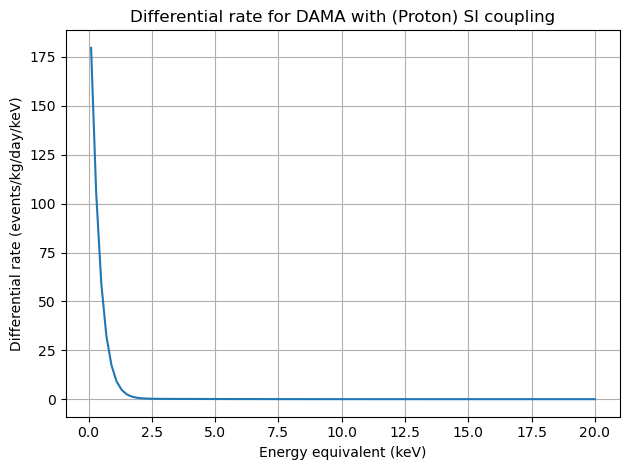

In [21]:
# Proton coupling to operator 1 (r=1): c^1_p=1/M**2 
wc = {'1': lambda M, r=1 : [(1.+r)/M**2,(1-r)/M**2]} # r: Proton-neutron coupling ratio, 
                                                     # M: Mass scale of the EFT interaction, usually the mass of the heavy mediator that has been integrated out of the theory
SI = WD.eft_hamiltonian('SI', wc)

# Initialize experiment that includes quenching factors for NaI
dama = WD.experiment("DAMA_LIBRA_2019")
nai = dama.target
# ['quenching' in dir(e) for e in nai.element]

# Standard halo function
vmin,delta_eta0=WD.streamed_halo_function()

# diff_rate routine
er_vec=np.linspace(0.1,20,100)
mchi=20.
diff_rate=[WD.diff_rate(nai, SI, mchi, er, vmin, delta_eta0,M=1e3,r=1) for er in er_vec]
plt.plot(er_vec,diff_rate)
plt.xlabel("Energy equivalent (keV)")
plt.ylabel("Differential rate (events/kg/day/keV)") 
plt.title("Differential rate for DAMA with (Proton) SI coupling")
plt.grid()
#plt.yscale('log')
plt.tight_layout()
plt.show()

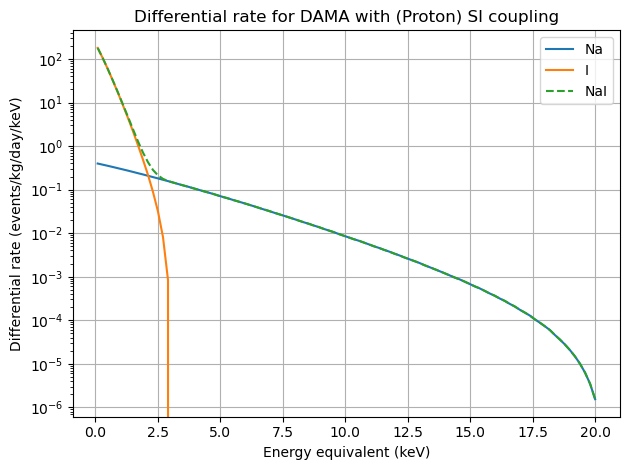

In [22]:
# Per element analysis
na,i=nai.element
diff_rate_nai=[WD.diff_rate(nai, SI, mchi, er, vmin, delta_eta0,M=1e3) for er in er_vec]
diff_rate_na=[WD.diff_rate(nai, SI, mchi, er, vmin, delta_eta0,elements_list=[na],M=1e3) for er in er_vec]
diff_rate_i=[WD.diff_rate(nai, SI, mchi, er, vmin, delta_eta0,elements_list=[i],M=1e3) for er in er_vec]
plt.plot(er_vec,diff_rate_na,label="Na")
plt.plot(er_vec,diff_rate_i,label="I")
plt.plot(er_vec,diff_rate_nai,label="NaI", linestyle='--')
plt.xlabel("Energy equivalent (keV)")
plt.ylabel("Differential rate (events/kg/day/keV)")
plt.yscale('log')
plt.title("Differential rate for DAMA with (Proton) SI coupling")
plt.legend()
plt.grid()  
plt.tight_layout()
plt.show()

### Integrated rate with detector response

loading c_1_c_1.npy
type: print_string(np.load('WimPyDD/Experiments/DAMA_LIBRA_2019/Response_functions/spin_1_2/c_1_c_1.npy',allow_pickle=True)[-1]) to get info about input used


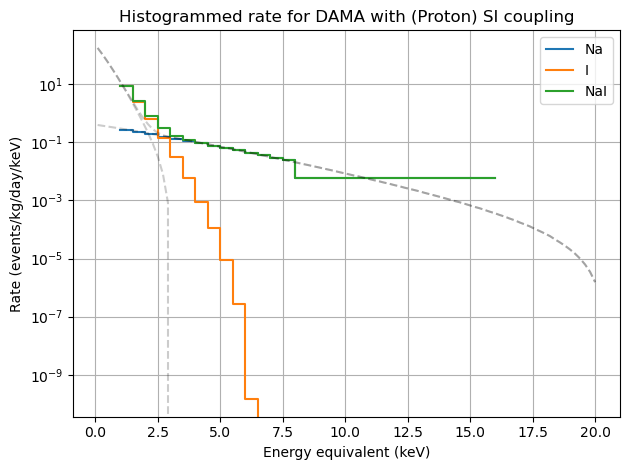

In [23]:
# Now also including the detectors response function
WD.load_response_functions(dama, SI, j_chi=0.5)
e, s0 = WD.wimp_dd_rate(dama, SI, vmin, delta_eta0, mchi=20, M=1e3, r=1)
e, s0_na = WD.wimp_dd_rate(dama, SI, vmin, delta_eta0, mchi=20, elements_list=[na], M=1e3, r=1)
e, s0_i = WD.wimp_dd_rate(dama, SI, vmin, delta_eta0, mchi=20, elements_list=[i], M=1e3, r=1)

# Loading data.tab
data = np.loadtxt('WimPyDD/Experiments/DAMA_LIBRA_2019/data.tab', skiprows=1)
bin_edges = np.unique(np.concatenate((data[:, 0], [data[-1, 1]])))

def extend_for_step(y):
    return np.append(y, y[-1])

plt.step(bin_edges, extend_for_step(s0_na), where='post', label='Na')
plt.step(bin_edges, extend_for_step(s0_i), where='post', label='I')
plt.step(bin_edges, extend_for_step(s0), where='post', label='NaI')

plt.plot(er_vec,diff_rate_na, linestyle='--', alpha=0.2, color='black')
plt.plot(er_vec,diff_rate_i, linestyle='--', alpha=0.2, color='black')
plt.plot(er_vec,diff_rate_nai, linestyle='--', alpha=0.2, color='black')

plt.xlabel("Energy equivalent (keV)")
plt.ylabel("Rate (events/kg/day/keV)")
plt.yscale('log')
plt.title("Histogrammed rate for DAMA with (Proton) SI coupling")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

#print_string(np.load('WimPyDD/Experiments/DAMA_LIBRA_2019/Response_functions/spin_1_2/c_1_c_1.npy',allow_pickle=True)[-1])

loading c_9_c_9.npy
type: print_string(np.load('WimPyDD/Experiments/DAMA_LIBRA_2019/Response_functions/spin_1_2/c_9_c_9.npy',allow_pickle=True)[-1]) to get info about input used


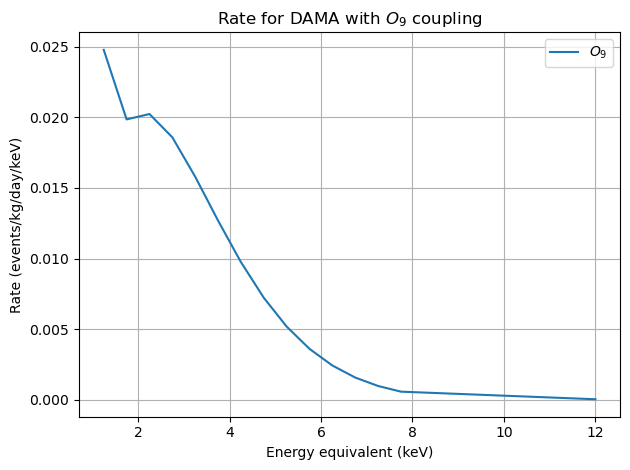

In [24]:
#Alternative use case (see WimPyDD paper)
def c9_tau(mchi,cross_section,r):
    hbarc2=0.389e-27
    mn=0.931
    mu=mchi*mn/(mchi+mn)
    cp=(np.pi*cross_section/(mu**2*hbarc2))**(1./2.)
    return cp*np.array([1.+r,1.-r])

c9=WD.eft_hamiltonian('c9',{9: c9_tau})
vmin,delta_eta1=WD.streamed_halo_function(yearly_modulation=True,n_vmin_bin=1000)
WD.load_response_functions(dama,c9)
e,s1=WD.wimp_dd_rate(dama, c9, vmin, delta_eta1, cross_section=8.29e-33, mchi=9.3 , r=4.36) # Values come from the best fit of the DAMA/LIBRA-Phase2 data

plt.plot(e, s1, label=r'$O_9$')
plt.xlabel("Energy equivalent (keV)")   
plt.ylabel("Rate (events/kg/day/keV)")
plt.title(r"Rate for DAMA with $O_9$ coupling")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

loading c_4_c_4.npy
type: print_string(np.load('WimPyDD/Experiments/DAMA_LIBRA_2019/Response_functions/spin_1_2/c_4_c_4.npy',allow_pickle=True)[-1]) to get info about input used
loading c_4_c_6.npy
type: print_string(np.load('WimPyDD/Experiments/DAMA_LIBRA_2019/Response_functions/spin_1_2/c_4_c_6.npy',allow_pickle=True)[-1]) to get info about input used
loading c_5_c_4.npy
type: print_string(np.load('WimPyDD/Experiments/DAMA_LIBRA_2019/Response_functions/spin_1_2/c_5_c_4.npy',allow_pickle=True)[-1]) to get info about input used
loading c_5_c_5.npy
type: print_string(np.load('WimPyDD/Experiments/DAMA_LIBRA_2019/Response_functions/spin_1_2/c_5_c_5.npy',allow_pickle=True)[-1]) to get info about input used
loading c_6_c_4.npy
type: print_string(np.load('WimPyDD/Experiments/DAMA_LIBRA_2019/Response_functions/spin_1_2/c_6_c_4.npy',allow_pickle=True)[-1]) to get info about input used
loading c_6_c_6.npy
type: print_string(np.load('WimPyDD/Experiments/DAMA_LIBRA_2019/Response_functions/spin_1_

c:\Users\nikla\Seafile\Studium\Master\Master Thesis\Master-Code\WimPyDD\package.py:3865: RuntimeWarning: invalid value encountered in sqrt
  return mu**2/mn*(vmin/300)**2-delta*mu/mn-(vmin/300)*mu**2/mn*np.sqrt((vmin/300)**2-2*delta/mu)
c:\Users\nikla\Seafile\Studium\Master\Master Thesis\Master-Code\WimPyDD\package.py:3842: RuntimeWarning: invalid value encountered in sqrt
  return mu**2/mn*(vmin/300)**2-delta*mu/mn+(vmin/300)*mu**2/mn*np.sqrt((vmin/300)**2-2*delta/mu)


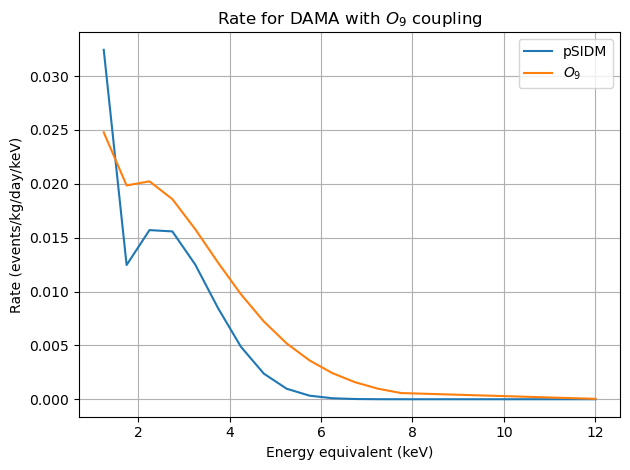

In [25]:
def c_tau(mchi,sigma,c_tilde):
    hbarc2=0.389e-27
    mn=0.931
    mu=mchi*mn/(mchi+mn)
    c_abs=(mu**2*hbarc2/(np.pi*sigma))**(-0.5)
    return c_abs*c_tilde

wc={4: lambda mchi,s,c: c_tau(mchi,s,c)[0:2],
    5: lambda mchi,s,c: c_tau(mchi,s,c)[2:4],
    6: lambda mchi,s,c: c_tau(mchi,s,c)[4:6]}

c_456=WD.eft_hamiltonian('c_456',wc)
WD.load_response_functions(dama,c_456)
c_tilde=np.array([-0.00139183, -0.00145925,-0.00318353, -0.01660634, 0.69199713, 0.72169939])
mchi=11.64102564102564
delta=23.73913043478261
cross_section=4.684124873205523e-28

plt.plot(*WD.wimp_dd_rate(dama,c_456,vmin,delta_eta1,mchi,delta=delta,s=cross_section,c=c_tilde), label="pSIDM")
plt.plot(e, s1, label=r'$O_9$')
plt.xlabel("Energy equivalent (keV)")   
plt.ylabel("Rate (events/kg/day/keV)")
plt.title(r"Rate for DAMA with $O_9$ coupling")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [26]:
xe=WD.target('Xe')
xenon1t=WD.experiment('XENON_1T_2018',xe)
WD.load_response_functions(xenon1t,c_456)
WD.wimp_dd_rate(xenon1t,c_456,vmin,delta_eta1,mchi,delta=delta,s=cross_section,c=c_tilde)
#(array([36.5]), array([4.78777365]))

loading c_4_c_4.npy
type: print_string(np.load('WimPyDD/Experiments/XENON_1T_2018/Response_functions/spin_1_2/c_4_c_4.npy',allow_pickle=True)[-1]) to get info about input used
loading c_4_c_6.npy
type: print_string(np.load('WimPyDD/Experiments/XENON_1T_2018/Response_functions/spin_1_2/c_4_c_6.npy',allow_pickle=True)[-1]) to get info about input used
loading c_5_c_4.npy
type: print_string(np.load('WimPyDD/Experiments/XENON_1T_2018/Response_functions/spin_1_2/c_5_c_4.npy',allow_pickle=True)[-1]) to get info about input used
loading c_5_c_5.npy
type: print_string(np.load('WimPyDD/Experiments/XENON_1T_2018/Response_functions/spin_1_2/c_5_c_5.npy',allow_pickle=True)[-1]) to get info about input used
loading c_6_c_4.npy
type: print_string(np.load('WimPyDD/Experiments/XENON_1T_2018/Response_functions/spin_1_2/c_6_c_4.npy',allow_pickle=True)[-1]) to get info about input used
loading c_6_c_6.npy
type: print_string(np.load('WimPyDD/Experiments/XENON_1T_2018/Response_functions/spin_1_2/c_6_c_6.np

(array([31.9]), array([1.87211292]))

### Exclusion Plot


In [27]:
# Example: Standard isoscalar SI interaction driven by the operator 1
hbarc2=0.389e-27
mn=0.931
wc_SI={1: lambda mchi,sigma_p: np.sqrt(sigma_p*np.pi/hbarc2)*(1./mn+1./mchi)*np.array([2.,0])} # Compare Born approximation for the SI interaction
SI=WD.eft_hamiltonian('SI',wc_SI)
mchi,sigma=WD.mchi_vs_exclusion(xenon1t, SI,vmin, delta_eta0)

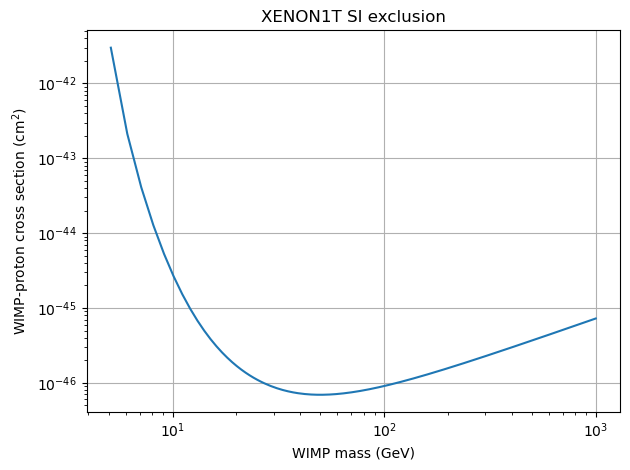

In [28]:
plt.plot(mchi,sigma)
plt.xlabel("WIMP mass (GeV)")
plt.ylabel("WIMP-proton cross section (cm$^2$)")
plt.xscale('log')
plt.yscale('log')
plt.title("XENON1T SI exclusion")
plt.grid()
plt.tight_layout()
plt.show()

In [29]:
# Alternative parametrization: c^p_1 = 1/M^2

SI_M=WD.eft_hamiltonian('SI_M',{1: lambda M: 1./M**2*np.array([2,0])})
mchi,one_over_M4=WD.mchi_vs_exclusion(xenon1t, SI_M, vmin, delta_eta0)

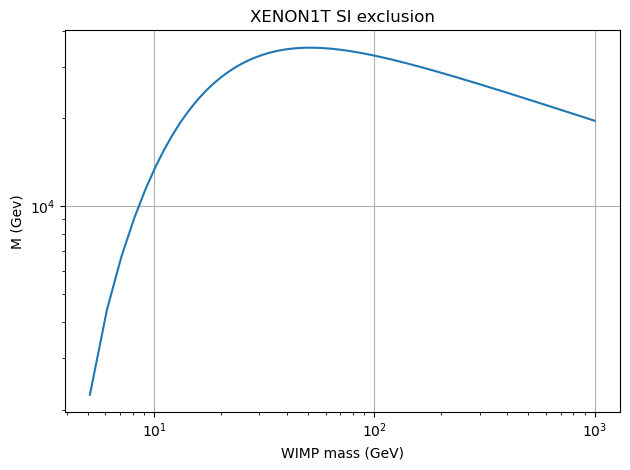

In [30]:
plt.plot(mchi,one_over_M4**(-1./4.))
plt.xlabel("WIMP mass (GeV)")
plt.ylabel("M (Gev)")
plt.xscale('log')
plt.yscale('log')
plt.title("XENON1T SI exclusion")
plt.grid()
plt.tight_layout()
plt.show()